<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 9: Discrete Fourier Transform (DFT)

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#frequency_content" style="color:black;">From Waveforms to Frequency Content</a></li>
    <li><a href="#background_inner" style="color:#1B5E20;"><strong>Background:</strong> The Geometric Meaning of Inner Products</a></li>
    <li><a href="#signal_inner" style="color:black;">Comparing Signals with Inner Products</a></li>
    <li><a href="#signal_phase" style="color:black;">The Role of Phase</a></li>
    <li><a href="#complex_exponentials" style="color:black;">Comparing Signals with Complex Exponentials</a></li>
    <li><a href="#dft" style="color:black;">Discrete Fourier Transform (DFT)</a></li>
    <li><a href="#background_complexity" style="color:#1B5E20;"><strong>Background:</strong> Computational Efficiency and the Power of Algorithms</a></li>
    <li><a href="#fft" style="color:black;">Fast Fourier Transform (FFT)</a></li>
    <li><a href="#exercise_leakage" style="color:#006064;"><strong>Exercise 1:</strong> Frequency Bins and Spectral Leakage</a></li>
    <li><a href="#exercise_missing_time" style="color:#006064;"><strong>Exercise 2:</strong> Frequency Content Without Time Localization</a></li>
    <li><a href="#exercise_dft_inverse" style="color:#006064;"><strong>Exercise 3:</strong> Inverse DFT and Signal Reconstruction</a></li>
</ul>

<a id="learn"></a>

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
A waveform shows how a signal changes over time, but it may not clearly reveal the oscillations from which the signal is built. <strong>Fourier analysis</strong> provides another perspective by representing a signal as a weighted superposition of sinusoids. The resulting <strong>frequency representation</strong>, or spectrum, reveals which frequencies occur and how strongly they contribute. In this unit, we study the <strong>discrete Fourier transform</strong> (DFT), which analyzes finite discrete-time signals. Building on complex exponentials and roots of unity from <a href="PCP_07_exp.html">Unit 7</a> and sampled signals from <a href="PCP_08_signal.html">Unit 8</a>, we interpret each Fourier coefficient as an inner product that compares the signal with a particular complex oscillation. We then examine the magnitude and phase of these coefficients, express the DFT as a matrix, reconstruct signals using the inverse DFT, and study the <strong>fast Fourier transform</strong> (FFT), which computes the same result much more efficiently. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
<li>Interpret an inner product as a comparison between finite signals.</li>
<li>Explain the DFT as a comparison with sampled complex exponentials.</li>
<li>Relate DFT indices to physical frequencies and interpret positive and negative frequencies.</li>
<li>Interpret the magnitude and phase of Fourier coefficients.</li>
<li>Explain frequency resolution, conjugate symmetry, and spectral leakage.</li>
<li>Construct the DFT matrix and reconstruct a signal using the inverse DFT.</li>
<li>Explain why the FFT is substantially faster than a direct DFT computation.</li>
</ul>

<p style="color:#E65100;">
The unit contains three exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_leakage">Exercise 1</a>: Explore frequency bins and spectral leakage.</li>
<li><a href="#exercise_missing_time">Exercise 2</a>: Explore how signals with similar frequency content can differ in their temporal organization.</li>
<li><a href="#exercise_dft_inverse">Exercise 3</a>: Construct the inverse DFT and use it to reconstruct a signal.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
The time-domain signal and its frequency-domain representation contain the same information but organize it differently. <strong>The DFT replaces the question of what happens at each moment with the question of which oscillations are present.</strong>
</p>

</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
from matplotlib import pyplot as plt
import timeit

# --- Custom utilities (Unit 9) ---
from libpcp.unit09 import (
    generate_sinusoid,
    generate_example_signal,
    exercise_leakage,
    exercise_missing_time,
    exercise_dft_inverse
)

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="frequency_content"></a>

## From Waveforms to Frequency Content

In <a href="PCP_08_signal.html#interference">Unit 8</a>, we constructed complex signals by adding simpler ones. Consider the signal

$$
\begin{aligned}
f(t)
={}&0.8\sin\bigl(2\pi(1.9t-0.3)\bigr)\\
&+0.5\sin\bigl(2\pi(6.1t-0.1)\bigr)\\
&+0.3\sin\bigl(2\pi(16t-0.2)\bigr).
\end{aligned}
$$

Its three sinusoidal components have different frequencies, amplitudes, and phases. When viewed separately, each oscillation is easy to recognize. Once they are added, however, they blend into a more complicated waveform, much as individual notes blend together in a musical sound.

The waveform describes how the signal changes over time, but it does not immediately reveal which oscillations are hidden inside it. A **frequency representation**, or **spectrum**, presents the same signal from another viewpoint: instead of organizing its values by time, it organizes its oscillatory content by frequency. For this example, we expect contributions near $1.9$, $6.1$, and $16$ Hz, with strengths related to their amplitudes.

Constructing the signal is easy when its ingredients are known: we simply add the three sinusoids. **Fourier analysis** tackles the more interesting reverse problem. Given only the resulting waveform, it asks which frequencies are present and how strongly they contribute. The following figure first shows the three ingredients separately and then the mixture they produce:

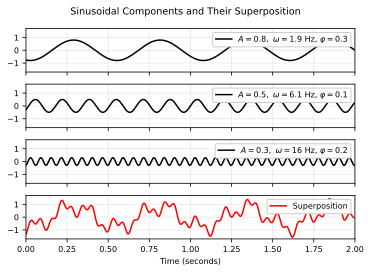

In [2]:
dur, sr = 2, 200
parameters = [
    (0.8, 1.9, 0.3),
    (0.5, 6.1, 0.1),
    (0.3, 16, 0.2),
]

components = [
    generate_sinusoid(dur=dur, amp=amp, freq=freq,
                      phase=phase, sr=sr)[0]
    for amp, freq, phase in parameters
]
x, t = generate_example_signal(dur=dur, sr=sr)

fig, axes = plt.subplots(
    4, 1, figsize=(5.2, 3.8), layout='tight',
    sharex=True, sharey=True,
)
fig.suptitle('Sinusoidal Components and Their Superposition')

for ax, signal, (amp, freq, phase) in zip(
        axes[:3], components, parameters):
    label = rf'$A={amp:g},\ \omega={freq:g}$ Hz, $\varphi={phase:g}$'
    ax.plot(t, signal, color='black', label=label)
    ax.legend(loc='upper right', framealpha=1)

axes[-1].plot(t, x, color='red', label='Superposition')
axes[-1].legend(loc='upper right', framealpha=1)

for ax in axes:
    ax.set(xlim=(0, dur), ylim=(-1.7, 1.7))
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (seconds)');

The first three plots show the individual sinusoids used to construct the signal. In the red superposition, these components are still present, but they are no longer easy to recognize by inspection. Before developing the mathematics, let us preview the central idea of **Fourier analysis**: we compare the sampled signal with suitable sinusoidal oscillations at many candidate frequencies between $0$ and $20$ Hz. Each comparison measures how strongly the signal agrees with one frequency. Plotting the resulting magnitudes against frequency produces a simple **spectrum**. Because the frequency components of this example are known, we mark them with red vertical lines. The following sections will explain the mathematics behind this procedure:

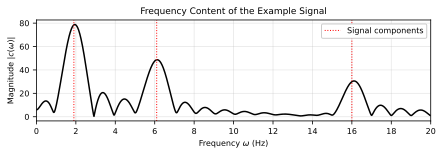

In [3]:
dur, sr = 1, 200
x, t = generate_example_signal(dur=dur, sr=sr)

freqs = np.linspace(0, 20, 1001)
magnitudes = np.zeros(len(freqs))

for k, freq in enumerate(freqs):
    e = np.exp(2j * np.pi * freq * t)
    magnitudes[k] = abs(np.vdot(e, x))

plt.figure(figsize=(6.2, 2.2), layout='tight')
plt.plot(freqs, magnitudes, color='black')

for k, freq in enumerate([1.9, 6.1, 16]):
    plt.axvline(
        freq, color='red', linestyle=':', linewidth=1,
        label='Signal components' if k == 0 else None,
    )

plt.title('Frequency Content of the Example Signal')
plt.xlabel(r'Frequency $\omega$ (Hz)')
plt.ylabel(r'Magnitude $|c(\omega)|$')
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 2))
plt.grid(alpha=0.3)
plt.legend(loc='upper right', framealpha=1);

The spectrum shows pronounced peaks near $1.9$, $6.1$, and $16$ Hz. Starting only from the superimposed waveform, the comparison has recovered the frequencies used to construct the signal. The largest peak occurs near $1.9$ Hz, reflecting the larger amplitude of this component. This is the change of perspective offered by Fourier analysis: the waveform organizes a signal over time, while its spectrum reveals the oscillations present at different frequencies. For now, the calculation may look like a useful numerical recipe. We next explain it step by step, beginning with the **inner product**, the mathematical tool underlying each comparison.

<a id="background_inner"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: The Geometric Meaning of Inner Products
</h2>

<div style="
  float:right;
  width:280px;
  max-width:48%;
  margin-left:20px;
  margin-bottom:10px;
  border:2px solid #1B5E20;
  padding:4px;
  background-color:white;
">
<img src="data/PCP_fig_inner_product.png"
     style="display:block; width:100%; height:auto;"
     alt="Geometric interpretation of inner products">
</div>

<p style="color:#1B5E20;">
Linear algebra allows us to treat a finite sequence of numbers as a vector. A vector with two or three coordinates can be drawn as an arrow. A signal with thousands of samples cannot, but the same geometric ideas still apply: it has a length, points in a direction, and can be compared with other vectors. Geometry therefore continues to work even when we can no longer draw the space. For real vectors $x,y\in\mathbb{R}^N$, the <strong>inner product</strong> is
$$
\langle x,y\rangle:=\sum_{n=0}^{N-1}x(n)y(n).
$$
The individual products reinforce or cancel one another, and their sum provides a single number describing the relationship between the vectors. The inner product determines the length, or <strong>norm</strong>, through $\|x\|:=\sqrt{\langle x,x\rangle}$. For nonzero vectors, it also determines their angle $\varphi$:
$$
\cos(\varphi)
=\frac{\langle x,y\rangle}{\|x\|\,\|y\|}.
$$
The normalized value is $1$ for the same direction, $-1$ for opposite directions, and $0$ for perpendicular directions. Perpendicular vectors are called <strong>orthogonal</strong>. Normalization matters because a large inner product may otherwise result simply from long vectors rather than similar directions.
</p>

<p style="color:#1B5E20;">
The complex numbers extend the real numbers, and the inner product can likewise be extended to complex vectors. This will be essential for Fourier analysis, where oscillations are represented by complex exponentials. For $x,y\in\mathbb{C}^N$, we use
$$
\langle x,y\rangle
:=\sum_{n=0}^{N-1}x(n)\overline{y(n)}.
$$
The conjugation ensures that $\langle x,x\rangle=\sum_{n=0}^{N-1}|x(n)|^2$ is real and nonnegative and can therefore still represent a squared length. Complex geometry is harder to visualize, but the main interpretation remains: the normalized magnitude $|\langle x,y\rangle|/(\|x\|\,\|y\|)$ lies between $0$ and $1$. Values near $1$ indicate strong alignment, while a value of $0$ means that the vectors are orthogonal and have no component in each other’s direction.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
The inner product also measures the <strong>component</strong> of one vector in a chosen direction. If $\|y\|=1$, the coefficient $\langle x,y\rangle$ describes how strongly $x$ is aligned with $y$. This interpretation remains valid when vectors represent audio signals, images, or other data rather than visible arrows. In Fourier analysis, the signal is the vector being examined, and the chosen directions are complex exponential vectors representing different frequencies. <strong>A Fourier coefficient measures the contribution of one such frequency direction to the signal.</strong>
</p>

<div style="clear:both;"></div>
</div>


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">
<p style="color:#E65100; margin:0;">
<strong>Convention matters:</strong> For real vectors, <code>np.dot(x, y)</code> computes the inner product directly, and the order does not matter because $\langle x,y\rangle=\langle y,x\rangle$. For complex vectors, <code>np.dot()</code> applies no complex conjugation and therefore does not compute the inner product defined above. Instead, we use <code>np.vdot()</code>. There is one detail to watch: <code>np.vdot(a, b)</code> conjugates its first argument, whereas our mathematical convention conjugates the second. Thus, $\langle x,y\rangle$ is computed as <code>np.vdot(y, x)</code>. Complex inner products are <strong>conjugate symmetric</strong>, meaning that $\langle x,y\rangle=\overline{\langle y,x\rangle}$. Swapping the arguments therefore preserves the magnitude but reverses the sign of the phase, which matters when interpreting complex Fourier coefficients.
</p>
</div>

<a id="signal_inner"></a>

## Comparing Signals with Inner Products

The previous <a href="#background_inner">background box</a> interpreted the inner product geometrically. We now apply it to finite signals. A signal consisting of $N$ samples can be represented as a vector

$$
x=\bigl(x(0),x(1),\ldots,x(N-1)\bigr)^\top\in\mathbb{R}^N,
$$

where $n=0,\ldots,N-1$ is the sample index. For two real-valued signals $x,y\in\mathbb{R}^N$, their inner product is

$$
\langle x,y\rangle
:=\sum_{n=0}^{N-1}x(n)y(n).
$$

This calculation compares the signals sample by sample. If both values are positive or both are negative, their product contributes positively. If they have opposite signs, it contributes negatively. Summing over all $N$ samples collects these agreements and disagreements into a single number. Signals that are similarly aligned tend to have a positive inner product, oppositely aligned signals tend to have a negative one, and orthogonal signals have inner product zero. This idea is closely related to **correlation**, which measures how well two signals align. More generally, correlation compares one signal with shifted versions of another. Here, no shift is applied, so the inner product may be regarded as their correlation at zero shift.

The result reflects both alignment and magnitude. Increasing the amplitude of either signal also increases the inner product, even when its shape remains unchanged. It is therefore an unnormalized measure of agreement rather than a comparison of shape alone. Its sign still carries useful information by distinguishing similar from opposite alignment. In the following example, we use the first second of our running signal at the sampling rate $F_{\mathrm{s}}=64$ Hz. The resulting vector $x\in\mathbb{R}^{64}$ contains $N=64$ samples indexed by $n=0,\ldots,63$. We compare $x$ with itself and with two unit-amplitude sinusoids, $y_1$ and $y_2$, at $2$ Hz and $6$ Hz. Their phases are selected to align well with nearby components of $x$. Finally, we compare the two sinusoids with each other. Each plot shows the signals over their sample indices and the corresponding real inner product:


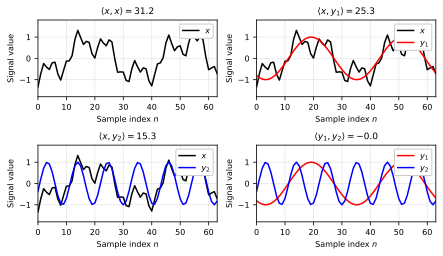

In [4]:
sr, dur = 64, 1
x, _ = generate_example_signal(dur=dur, sr=sr)
y1, _, _ = generate_sinusoid(dur=dur, freq=2, phase=0.35, sr=sr)
y2, _, _ = generate_sinusoid(dur=dur, freq=6, phase=0.06, sr=sr)

N = len(x)
n = np.arange(N)


def plot_inner_product_real(ax, n, x, y, label_x, label_y,
                            color_x='black', color_y='red'):
    """Plot two real signals and their inner product."""
    ax.plot(n, x, color=color_x, label=rf'${label_x}$')
    if y is not x:
        ax.plot(n, y, color=color_y, label=rf'${label_y}$')

    value = np.dot(x, y)
    ax.set(
        xlim=(n[0], n[-1]), ylim=(-1.8, 1.8),
        xlabel='Sample index $n$', ylabel='Signal value',
        title=rf'$\langle {label_x},{label_y}\rangle={value:.1f}$',
    )
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', framealpha=1)


comparisons = [
    (x,  x,  'x',   'x',   'black', 'black'),
    (x,  y1, 'x',   'y_1', 'black', 'red'),
    (x,  y2, 'x',   'y_2', 'black', 'blue'),
    (y1, y2, 'y_1', 'y_2', 'red',   'blue'),
]

fig, axes = plt.subplots(2, 2, figsize=(6.2, 3.6), layout='tight')

for ax, (u, v, label_u, label_v, color_u, color_v) in zip(
        axes.flat, comparisons):
    plot_inner_product_real(
        ax, n, u, v, label_u, label_v,
        color_x=color_u, color_y=color_v,
    )

The figure illustrates how the inner product summarizes agreement between finite signals:

* Comparing $x$ with itself gives $\langle x,x\rangle=31.2$. This value equals $\lVert x\rVert^2$ and may be interpreted as the energy of the finite signal.
* The broad oscillations of $x$ align well with the $2$ Hz sinusoid $y_1$, producing the relatively large value $\langle x,y_1\rangle=25.3$.
* The finer oscillations captured by the $6$ Hz sinusoid $y_2$ produce the smaller but still noticeable value $\langle x,y_2\rangle=15.3$.
* The two sinusoids complete different integer numbers of cycles over the one-second interval. Their positive and negative products cancel, giving $\langle y_1,y_2\rangle\approx0$. They are therefore orthogonal over these $N=64$ samples.

These comparisons reveal prominent components near $2$ Hz and $6$ Hz in $x$. This is already the central idea of **Fourier analysis**: compare a finite signal with oscillations of different frequencies and use the resulting inner products to measure how strongly each frequency is represented. However, we selected the phases of $y_1$ and $y_2$ carefully. We next examine why phase matters and how an unsuitable phase can hide an oscillation that is present in the signal.

<a id="signal_phase"></a>
## The Role of Phase

In the preceding example, the phases of $y_1$ and $y_2$ were chosen to align well with corresponding oscillations in $x$. This choice matters: even when two signals have the same frequency, their inner product may be small because their oscillations are shifted relative to each other. To examine this effect, consider the family of finite sampled sinusoids

$$
g_{\omega,\varphi}(n)
:=\sin\left(2\pi\left(
\omega\frac{n}{F_{\mathrm{s}}}-\varphi
\right)\right),
\qquad n=0,\ldots,N-1.
$$

The frequency $\omega$ determines how rapidly the sinusoid oscillates, while the phase $\varphi\in[0,1)$ determines its position within one cycle. The difference between the phases of two sinusoids is called a **phase shift**.

We retain $N=64$ and $F_{\mathrm{s}}=64$ Hz, fix the frequency at $\omega=2$ Hz, and vary only the phase. The following figure begins with the well-aligned phase $\varphi=0.35$ and then shifts the sinusoid in successive quarter-cycle steps. Initially, the inner product is large and positive. After a quarter-cycle shift, positive and negative contributions nearly cancel. A half-cycle shift reverses the sinusoid and produces a large negative value, while the final quarter-cycle shift again gives a value close to zero. All four comparison signals have the same frequency and amplitude; only their phases differ:

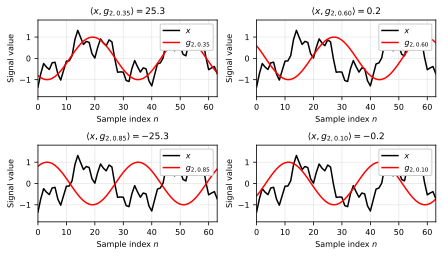

In [5]:
freq, phase_start = 2, 0.35
phases = (phase_start + 0.25 * np.arange(4)) % 1

fig, axes = plt.subplots(2, 2, figsize=(6.2, 3.6), layout='tight')

for ax, phase in zip(axes.flat, phases):
    g, _, _ = generate_sinusoid(
        dur=dur, freq=freq, phase=phase, sr=sr
    )
    label = rf'g_{{{freq},{phase:.2f}}}'
    plot_inner_product_real(ax, n, x, g, 'x', label)

<a id="complex_exponentials"></a>

## Comparing Signals with Complex Exponentials

The preceding section revealed a difficulty: the inner product with a real sinusoid depends strongly on its phase. Testing every possible phase would require many separate comparisons. A complex exponential solves this problem more efficiently by combining a cosine and a sine of the same frequency. Since these oscillations differ by a quarter cycle, together they account for every possible phase. For a frequency $\omega$, define the complex-valued vector

$$
e_\omega(n)
:=\exp\left(2\pi i\omega\frac{n}{F_{\mathrm{s}}}\right),
\qquad n=0,\ldots,N-1.
$$

Using <a href="PCP_07_exp.html#euler">Euler's formula</a>, we obtain

$$
e_\omega(n)
=
\cos\left(2\pi\omega\frac{n}{F_{\mathrm{s}}}\right)
+i\sin\left(2\pi\omega\frac{n}{F_{\mathrm{s}}}\right).
$$

Thus, $\operatorname{Re}(e_\omega)$ is a cosine and $\operatorname{Im}(e_\omega)$ is a sine. Both are real-valued vectors in $\mathbb{R}^N$, while their combination $e_\omega$ belongs to $\mathbb{C}^N$.

Because $e_\omega$ is complex-valued, comparing it with a signal requires the complex inner product introduced in the <a href="#background_inner">background box</a>. The signal $x$ may belong to $\mathbb{R}^N$ or $\mathbb{C}^N$. Since every real-valued vector can also be regarded as a complex-valued one, the same complex inner product applies in both cases:

$$
c(\omega)
:=\langle x,e_\omega\rangle
=\sum_{n=0}^{N-1}x(n)\overline{e_\omega(n)}.
$$

For a real-valued signal $x\in\mathbb{R}^N$, this complex coefficient separates into two real comparisons:

$$
c(\omega)
=
\left\langle x,\operatorname{Re}(e_\omega)\right\rangle
-i\left\langle x,\operatorname{Im}(e_\omega)\right\rangle.
$$

The real part of $c(\omega)$ records the comparison with the cosine, while its negative imaginary part records the comparison with the sine. Together, they determine the real sinusoid of frequency $\omega$ that aligns most strongly with $x$:

* The magnitude $|c(\omega)|$ gives the strongest possible agreement with a unit-amplitude sinusoid of frequency $\omega$.
* The angle of $c(\omega)$ determines the phase at which this strongest agreement occurs.

With the phase convention used in this unit, the optimal cosine phase is

$$
\varphi_\omega
=-\frac{\arg(c(\omega))}{2\pi}
\pmod 1.
$$

Here, $\arg(c(\omega))$ is the angle of the complex coefficient in radians. Dividing by $2\pi$ converts this angle into cycles, while “modulo $1$” reflects that phases differing by one complete cycle describe the same sinusoid. The minus sign results from the complex conjugation in the inner product. Denoting the unit-amplitude cosine with frequency $\omega$ and optimal phase $\varphi_\omega$ by $\cos_{\omega,\mathrm{opt}}$, we obtain the central relationship

$$
|c(\omega)|
=\left\langle x,\cos_{\omega,\mathrm{opt}}\right\rangle.
$$

In other words, two fixed comparisons, one with a cosine and one with a sine, replace a search through all possible phases. The angle of $c(\omega)$ identifies the optimal phase, while its magnitude equals the agreement obtained at that phase.

This **optimal-phase property** applies directly to real-valued signals $x\in\mathbb{R}^N$. For a general complex-valued signal $x\in\mathbb{C}^N$, the coefficient $c(\omega)$ still measures agreement with the complex frequency vector $e_\omega$, but it does not reduce to a comparison with a single real sinusoid. The optimal-phase result is important but not immediately obvious; it follows from Euler's formula and the angle-difference identities for sine and cosine. A complete derivation and a broader treatment of Fourier analysis can be found in Chapter 2 of the textbook <a href="https://www.audiolabs-erlangen.de/fau/professor/mueller/bookFMP">Fundamentals of Music Processing</a>.

The following figures make the relationship visible for our real-valued running signal and the frequency $\omega=2$ Hz. The first shows $x$ together with the cosine and sine contained in $e_2$. The second shows the optimally phased cosine determined by $c(2)$. Its inner product with $x$ equals the magnitude $|c(2)|$:

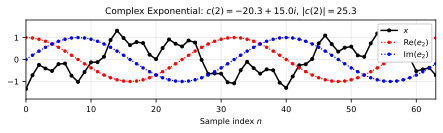

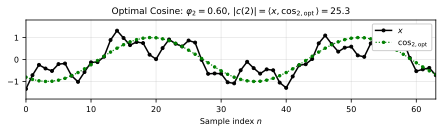

In [6]:
sr, freq = 64, 2
x, _ = generate_example_signal(dur=1, sr=sr)


def plot_frequency_comparison(ax, x, freq, sr, show_optimal=False):
    """Compare a signal with a complex exponential or optimal cosine."""
    N = len(x)
    n = np.arange(N)
    e = np.exp(2j * np.pi * freq * n / sr)
    c = np.vdot(e, x)

    ax.plot(n, x, 'ko-', ms=3, lw=1.5, label='$x$')

    if show_optimal:
        phase = (-np.angle(c) / (2 * np.pi)) % 1
        cos_opt = np.cos(2 * np.pi * (freq * n / sr - phase))
        value = np.dot(x, cos_opt)
        ax.plot(n, cos_opt, 'g:o', ms=2.5, lw=1.2,
                label=rf'$\cos_{{{freq},\mathrm{{opt}}}}$')
        title = (
            rf'Optimal Cosine: $\varphi_{{{freq}}}={phase:.2f}$, '
            rf'$|c({freq})|=\langle x,\cos_{{{freq},\mathrm{{opt}}}}\rangle'
            rf'={value:.1f}$'
        )
    else:
        ax.plot(n, e.real, 'r:o', ms=2.5, lw=1.2,
                label=rf'$\operatorname{{Re}}(e_{{{freq}}})$')
        ax.plot(n, e.imag, 'b:o', ms=2.5, lw=1.2,
                label=rf'$\operatorname{{Im}}(e_{{{freq}}})$')
        title = (
            rf'Complex Exponential: $c({freq})={c.real:.1f}{c.imag:+.1f}i$, '
            rf'$|c({freq})|={abs(c):.1f}$'
        )

    ax.set(xlim=(0, N - 1), ylim=(-1.8, 1.8),
           xlabel='Sample index $n$', title=title)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', framealpha=1)


for show_optimal in [False, True]:
    fig, ax = plt.subplots(figsize=(6.2, 1.9), layout='tight')
    plot_frequency_comparison(ax, x, freq, sr, show_optimal)

<a id="dft"></a>

## Discrete Fourier Transform (DFT)

In the introductory example, we compared the signal with sinusoidal oscillations at many candidate frequencies between $0$ and $20$ Hz. In principle, we could evaluate this comparison on an increasingly fine frequency grid, but we could never consider every real-valued frequency. Such a calculation would be computationally impossible and unnecessarily redundant: a signal with only $N$ samples has just $N$ independent values, so $N$ suitably chosen frequency coefficients are enough to describe it completely.

But which $N$ frequencies should we choose? The **discrete Fourier transform (DFT)** makes a practical and mathematically natural choice. For a signal $x\in\mathbb{R}^N$ sampled at the rate $F_{\mathrm{s}}$, it selects oscillations whose phases advance by an integer number of complete cycles over $N$ sampling steps. Their frequencies are

$$
\omega_k:=\frac{kF_{\mathrm{s}}}{N},
\qquad k=0,\ldots,N-1.
$$

Here, $k$ is the **frequency index**, and $\omega_k$ is the corresponding frequency in hertz. Neighboring frequencies are separated by the constant distance

$$
\Delta\omega:=\frac{F_{\mathrm{s}}}{N},
$$

called the **frequency-bin spacing** or **frequency resolution**. This formula connects the frequency grid directly to the observed time interval. The $N$ samples cover $N/F_{\mathrm{s}}$ seconds, so observing a signal for longer at the same sampling rate produces more samples and finer frequency spacing.

For our running example, $N=64$ and $F_{\mathrm{s}}=64$ Hertz. The signal covers one second, and the frequency spacing is $\Delta\omega=1$ Hertz. Thus, $\omega_k=k$ Hertz: in this special case, the frequency index $k$ directly gives the frequency in Hertz. More generally, the complex oscillations selected above have a remarkably regular structure and are **mutually orthogonal** over the $N$ sample positions. As we will see, this allows every finite signal to be represented by exactly $N$ frequency coefficients and **reconstructed without loss**. The same symmetry also provides the structure exploited by the fast Fourier transform. The following figure makes the frequency grid visible in the time domain. It shows the real and imaginary parts of four selected oscillations. The frequency index $k$ specifies how many complete cycles each oscillation performs over $N$ sampling steps:

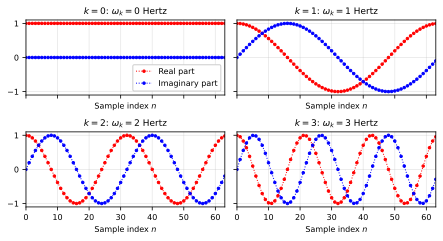

In [7]:
N = sr = 64
n = np.arange(N)
indices = [0, 1, 2, 3]

fig, axes = plt.subplots(
    2, 2, figsize=(6.2, 3.4), layout='tight',
    sharex=True, sharey=True,
)

for ax, k in zip(axes.flat, indices):
    freq = k * sr / N
    e = np.exp(2j * np.pi * k * n / N)

    ax.plot(n, e.real, 'r:o', ms=2.5, lw=1, label='Real part')
    ax.plot(n, e.imag, 'b:o', ms=2.5, lw=1, label='Imaginary part')
    ax.set(
        xlim=(0, N - 1), ylim=(-1.1, 1.1),
        xlabel='Sample index $n$',
        title=rf'$k={k}$: $\omega_k={freq:g}$ Hertz',
    )
    ax.grid(alpha=0.3)

axes[0, 0].legend(loc='lower right', framealpha=1);

The DFT collects the comparisons with all $N$ selected frequency vectors into a single matrix, called the **DFT matrix**. This complex-valued matrix $\mathrm{DFT}_N\in\mathbb{C}^{N\times N}$ is defined by

$$
\mathrm{DFT}_N(k,n)
:=\exp\left(-2\pi i\frac{kn}{N}\right),
\qquad k,n=0,\ldots,N-1.
$$
in 
For a real-valued signal $x\in\mathbb{R}^N$, its DFT is the complex-valued vector $X\in\mathbb{C}^N$ obtained through the matrix–vector product

$$
X:=\mathrm{DFT}_N\cdot x.
$$

The DFT coefficient at frequency index $k$ is therefore

$$
X(k)
=\sum_{n=0}^{N-1}x(n)
\exp\left(-2\pi i\frac{kn}{N}\right)
=\langle x,e_k\rangle.
$$

Thus, the $k^\mathrm{th}$ row of $\mathrm{DFT}_N$ contains the transposed conjugate frequency vector $\overline{e_k}^{\top}$. Each row compares $x$ with one frequency, and together the $N$ rows produce the complete frequency representation $X$. The structure of the matrix becomes especially clear when expressed using the <a href="PCP_07_exp.html#roots">roots of unity</a>. Let

$$
\rho_N:=\exp\left(\frac{2\pi i}{N}\right),
\qquad
\sigma_N:=\overline{\rho_N}
=\exp\left(-\frac{2\pi i}{N}\right).
$$

Both are primitive $N^\mathrm{th}$ roots of unity. The value $\rho_N$ represents one counterclockwise angular step of $2\pi/N$ around the unit circle, while $\sigma_N$ represents the corresponding clockwise step. Since

$$
\sigma_N^{kn}
=\exp\left(-2\pi i\frac{kn}{N}\right),
$$

the DFT matrix consists entirely of powers of $\sigma_N$:

$$
\mathrm{DFT}_N
=
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1\\
1 & \sigma_N & \sigma_N^2 & \cdots & \sigma_N^{N-1}\\
1 & \sigma_N^2 & \sigma_N^4 & \cdots & \sigma_N^{2(N-1)}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & \sigma_N^{N-1} & \sigma_N^{2(N-1)}
& \cdots & \sigma_N^{(N-1)(N-1)}
\end{pmatrix}.
$$

Each row of $\mathrm{DFT}_N$ represents one frequency index $k$, while each column corresponds to one sample index $n$. The matrix entries have modulus $1$, but their real and imaginary parts vary between $-1$ and $1$ as the powers of $\sigma_N$ rotate around the unit circle. In the following visualization, red represents positive values, blue represents negative values, and white represents values near zero. The resulting repetitions, reflections, and oscillatory patterns reveal the highly regular structure of the DFT matrix:

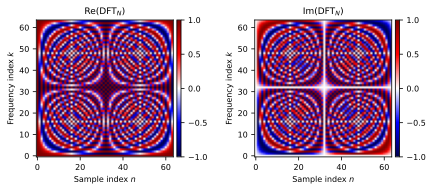

In [8]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


def generate_matrix_dft(N):
    """Generate the N x N DFT matrix."""
    n = np.arange(N)
    return np.exp(-2j * np.pi * n[:, None] * n / N)


N = 64
dft = generate_matrix_dft(N)
fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.7), layout='tight')

for ax, values, part in zip(
        axes, [dft.real, dft.imag], ['Re', 'Im']):
    image = ax.imshow(values, origin='lower', cmap='seismic',
                      vmin=-1, vmax=1, aspect='equal')
    ax.set(title=rf'$\operatorname{{{part}}}(\mathrm{{DFT}}_N)$',
           xlabel='Sample index $n$', ylabel='Frequency index $k$')

    cax = make_axes_locatable(ax).append_axes('right', size='3%', pad=0.05)
    fig.colorbar(image, cax=cax, ticks=[-1, -0.5, 0, 0.5, 1])

We have seen that the DFT transforms a time-domain signal $x\in\mathbb{R}^N$ into a frequency-domain vector $X\in\mathbb{C}^N$ through the matrix–vector product $X=\mathrm{DFT}_N\cdot x$. The vector $X$ contains one complex coefficient $X(k)$ for each frequency index $k$. Its magnitude $|X(k)|$ indicates the strength of the corresponding frequency, while its angle contains phase information.

Interpreting the frequency indices requires some care. Because of sampling, frequencies that differ by an integer multiple of the sampling rate produce the same samples. This is the frequency-domain version of the **aliasing phenomenon** discussed in <a href="PCP_08_signal.html#aliasing">Unit 8</a>. Consequently, indices above $N/2$ do not describe genuinely new high-frequency oscillations. Their samples agree with lower-frequency oscillations rotating in the opposite direction, so they are interpreted as **negative frequencies**. More precisely, the frequency associated with index $N-k$ differs from $-kF_{\mathrm{s}}/N$ by exactly one sampling rate:

$$
\frac{(N-k)F_{\mathrm{s}}}{N}
=
F_{\mathrm{s}}-\frac{kF_{\mathrm{s}}}{N}
\quad\longleftrightarrow\quad
-\frac{kF_{\mathrm{s}}}{N}.
$$

The arrow indicates that the two frequencies produce the same sampled oscillation. For example, when $N=F_{\mathrm{s}}=64$, index $62$ may formally suggest $62$ Hertz, but it equivalently represents $62-64=-2$ Hertz. Similarly, indices $58$ and $48$ represent $-6$ and $-16$ Hertz. For even $N$, the indices $0,\ldots,N/2$ cover the nonnegative frequencies up to the Nyquist frequency, while the remaining indices represent negative frequencies.

For a real-valued signal, the positive- and negative-frequency coefficients are closely related. They satisfy the **conjugate-symmetry** property

$$
X(N-k)=\overline{X(k)},
\qquad
|X(N-k)|=|X(k)|,
\qquad k=1,\ldots,N-1.
$$

The magnitudes at opposite frequencies are therefore equal. This symmetry has an intuitive explanation: a real sinusoid can be formed by combining two complex oscillations that rotate at the same rate in opposite directions. When the DFT coefficients are arranged from negative to positive frequencies, the magnitude spectrum of a real signal consequently appears symmetric around $0$ Hertz.

The following implementation constructs the DFT matrix and applies it using the Python matrix-multiplication operator `@`. The first figure shows the signal and its DFT coefficients in their original storage order, with frequency indices $k=0,\ldots,N-1$. The second figure uses `np.fft.fftshift()` to reorder the same coefficients from negative to positive frequency indices. Both figures retain the discrete representation: the signal is displayed over sample indices $n$, and its spectrum over frequency indices $k$:

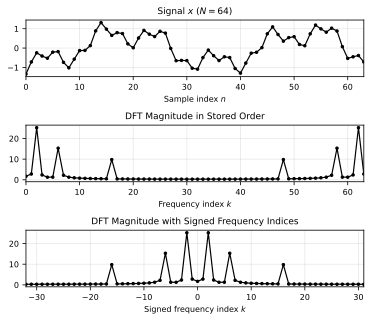

In [9]:
def dft(x):
    """Compute the discrete Fourier transform."""
    return generate_matrix_dft(len(x)) @ x


def plot_signal_dft(x, X, sr, physical_axes=False, figsize=None):
    """Plot a signal and its DFT using index or physical coordinates."""
    N = len(x)
    n = np.arange(N)
    magnitude = np.abs(X)

    if physical_axes:
        freq = np.fft.fftshift(np.fft.fftfreq(N, d=1 / sr))
        data = [
            (n / sr, x, rf'Signal $x$ ($N={N}$)', 'Time (seconds)'),
            (freq, np.fft.fftshift(magnitude), 'DFT Magnitude',
             'Frequency (Hertz)'),
        ]
        figsize = figsize or (5.2, 3.0)
    else:
        k = np.arange(N)
        k_signed = np.arange(-(N // 2), (N + 1) // 2)
        data = [
            (n, x, rf'Signal $x$ ($N={N}$)', 'Sample index $n$'),
            (k, magnitude, 'DFT Magnitude in Stored Order',
             'Frequency index $k$'),
            (k_signed, np.fft.fftshift(magnitude),
             'DFT Magnitude with Signed Frequency Indices',
             'Signed frequency index $k$'),
        ]
        figsize = figsize or (5.2, 4.5)

    fig, axes = plt.subplots(len(data), 1, figsize=figsize, layout='tight')

    for ax, (axis, values, title, xlabel) in zip(axes, data):
        ax.plot(axis, values, 'ko-', ms=2.5, lw=1.2)
        ax.set(title=title, xlabel=xlabel, xlim=(axis[0], axis[-1]))
        ax.grid(alpha=0.3)

sr = 64
x, _ = generate_example_signal(dur=1, sr=sr)
X = dft(x)

plot_signal_dft(x, X, sr)

The first two figures use the natural coordinates of finite vectors: $n$ identifies a sample, and $k$ identifies a frequency coefficient. To connect these indices with physical time and frequency, we use the sampling rate $F_{\mathrm{s}}$. Sample index $n$ corresponds to the time

$$
t_n=\frac{n}{F_{\mathrm{s}}},
$$

while signed frequency index $k$ corresponds to

$$
\omega_k=\frac{kF_{\mathrm{s}}}{N}
=k\,\Delta\omega.
$$

This conversion does not change the signal or its DFT; it only rescales the axes into seconds and Hertz. For our example, $N=F_{\mathrm{s}}=64$, so one sample step corresponds to $1/64$ second and one frequency step corresponds to $1$ Hertz. The following figure displays the same data using these physical units:

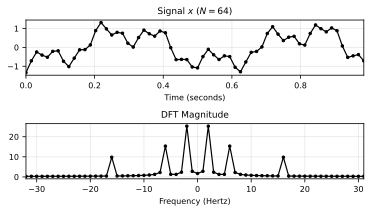

In [10]:
plot_signal_dft(x, X, sr, physical_axes=True)

The physical frequency axis reveals prominent contributions near $\pm2$, $\pm6$, and $\pm16$ Hertz. The spectrum is symmetric because $x$ is real-valued: every positive-frequency component has a corresponding negative-frequency component of equal magnitude. The component at $16$ Hertz lies exactly on the DFT grid, while $1.9$ and $6.1$ Hertz lie between neighboring grid points and spread across several coefficients. This phenomenon is called **spectral leakage** and will be explored in <a href="#exercise_leakage">Exercise 1</a>. The DFT is also invertible, meaning that the original signal can be reconstructed from its complex coefficients without loss, as explored in <a href="#exercise_dft_inverse">Exercise 3</a>.

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">
<p style="color:#E65100; margin-top:0;">
<strong>Note: One-Sided Magnitude Spectra and Normalization.</strong>
For a real-valued signal, the DFT coefficients at corresponding positive and negative frequencies are complex conjugates and therefore have equal magnitudes. The negative-frequency half of the magnitude spectrum thus repeats information already contained in the positive-frequency half. For this reason, magnitude spectra of real-valued signals are often displayed using only the nonnegative-frequency indices $k=0,\ldots,N/2$ for even $N$. This representation is called a <strong>one-sided magnitude spectrum</strong>.
</p>

<p style="color:#E65100; margin-bottom:0;">
A separate issue concerns <strong>normalization</strong>. Because the DFT used here has no scaling factor, its magnitudes grow with the signal length $N$. For an amplitude-oriented one-sided spectrum, divide the magnitudes by $N$ and double those at positive frequencies below <code>sr/2</code>. Do not double the values at <code>0</code> Hz or <code>sr/2</code>, since each is its own positive- and negative-frequency counterpart. With this normalization, a bin-centered sinusoid of amplitude <code>a</code> produces a peak of height <code>a</code>. Another normalization approach multiplies the DFT coefficients by $1/\sqrt{N}$. This gives the <strong>unitary DFT</strong>, which preserves the norm, and therefore the energy, when transforming a signal from the time domain to the frequency domain.
</p>
</div>

<a id="background_complexity"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Computational Efficiency and the Power of Algorithms
</h2>

<p style="color:#1B5E20;">
What makes one computation faster than another? How can algorithms be compared independently of the computers on which they run? And why can a clever algorithm matter more than faster hardware? Measured runtime alone cannot answer these questions because it also depends on the processor, programming language, and implementation. Instead, we consider the <strong>computational work</strong>: the number of basic operations required to solve the problem. What counts as one operation depends on the chosen computational model. In our discussion of the DFT, we count arithmetic operations such as adding or multiplying real or complex numbers. We then examine how the number of these operations grows with the input size $N$. This growth is described using <strong>big-$\mathcal{O}$ notation</strong>. It ignores machine-dependent details and constant factors and focuses on the dominant behavior for large inputs. The following table compares three common growth rates:
</p>

<table style="
  width:65%;
  border-collapse:collapse;
  table-layout:fixed;
  margin:10px auto;
  color:#1B5E20;
  text-align:left;
  font-size:95%;
">
  <colgroup>
    <col style="width:27%;">
    <col style="width:31%;">
    <col style="width:42%;">
  </colgroup>
  <thead>
    <tr style="background-color:#E8F5E9;">
      <th style="border:1px solid #81C784; padding:4px 6px; text-align:left;">Complexity</th>
      <th style="border:1px solid #81C784; padding:4px 6px; text-align:left;">Growth</th>
      <th style="border:1px solid #81C784; padding:4px 6px; text-align:left;">Work after doubling $N$</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color:white;">
      <td style="border:1px solid #81C784; padding:4px 6px;">$\mathcal{O}(N)$</td>
      <td style="border:1px solid #81C784; padding:4px 6px;">Linear</td>
      <td style="border:1px solid #81C784; padding:4px 6px;">About $2$ times</td>
    </tr>
    <tr style="background-color:white;">
      <td style="border:1px solid #81C784; padding:4px 6px;">$\mathcal{O}(N\log_2N)$</td>
      <td style="border:1px solid #81C784; padding:4px 6px;">Nearly linear</td>
      <td style="border:1px solid #81C784; padding:4px 6px;">Slightly more than $2$ times</td>
    </tr>
    <tr style="background-color:white;">
      <td style="border:1px solid #81C784; padding:4px 6px;">$\mathcal{O}(N^2)$</td>
      <td style="border:1px solid #81C784; padding:4px 6px;">Quadratic</td>
      <td style="border:1px solid #81C784; padding:4px 6px;">About $4$ times</td>
    </tr>
  </tbody>
</table>

<p style="color:#1B5E20;">
Big-$\mathcal{O}$ notation does not predict an exact runtime. For small inputs, overhead and implementation details may dominate. For large inputs, however, the growth rate becomes decisive. Consider a signal with $N=65\,536=2^{16}$ samples:
$$
N^2\approx4.3\cdot10^9,
\qquad
N\log_2N\approx1.0\cdot10^6.
$$
These values are not exact operation counts, but their ratio reveals the enormous difference in scale:
$$
\frac{N^2}{N\log_2N}
=\frac{65\,536}{16}
=4096.
$$
At this input size, an $\mathcal{O}(N\log_2N)$ algorithm requires only about $1/4096$ of the work of an $\mathcal{O}(N^2)$ algorithm. Its measured runtime need not improve by exactly the same factor, but the message is hard to miss: a better algorithm can leave faster hardware far behind.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
The DFT provides a compelling example. Computing it directly means multiplying the dense $N\times N$ DFT matrix by a signal vector, which requires on the order of $N^2$ operations. The <strong>fast Fourier transform (FFT)</strong> exploits the symmetry of the DFT matrix and reorganizes the computation into approximately $\log_2N$ stages. Each stage can be represented by a sparse $N\times N$ matrix containing only $\mathcal{O}(N)$ nonzero entries, so its matrix–vector product requires only $\mathcal{O}(N)$ operations. Combining the stages gives the total complexity
$$
\mathcal{O}(N)\cdot\mathcal{O}(\log_2N)
=\mathcal{O}(N\log_2N).
$$
The FFT produces exactly the same Fourier coefficients. The mathematics is unchanged, but the route to the answer is dramatically shorter. This clever reorganization made large-scale Fourier analysis practical and helped transform digital audio, telecommunications, medical imaging, radar, astronomy, and scientific computing. Few algorithms can honestly claim to have changed entire industries; the FFT is one of them.
</p>
</div>

<a id="fft"></a>

## Fast Fourier Transform (FFT)

We now turn to the famous **fast Fourier transform (FFT)**. As discussed in the <a href="#background_complexity">background box on computational efficiency</a>, the FFT is not a different transform but a faster algorithm for computing exactly the same DFT. Its central idea was already known to Gauss around 1805 and was rediscovered and popularized by James Cooley and John Tukey in 1965. Their approach is now commonly known as the <a href="https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm">Cooley–Tukey FFT algorithm</a>.

The main idea is that, for an even signal length $N$, one DFT can be constructed from two shorter DFTs of length $N/2$. This decomposition exploits algebraic relationships among the entries of the corresponding DFT matrices. Recall from <a href="PCP_07_exp.html#roots">Unit 7</a> that the DFT matrix of size $N$ is constructed from powers of the primitive $N^\mathrm{th}$ **root of unity**

$$
\sigma_N:=\exp\left(-\frac{2\pi i}{N}\right).
$$

The corresponding root for a DFT of size $N/2$ satisfies

$$
\sigma_{N/2}
=\exp\left(-\frac{2\pi i}{N/2}\right)
=\exp\left(-\frac{4\pi i}{N}\right)
=\sigma_N^2.
$$

This close relationship allows a DFT of length $N$ to reuse the results of two DFTs of length $N/2$. We begin by separating the signal $x$ into its even- and odd-indexed samples and computing the DFT of each subsequence:

$$
\begin{aligned}
A
&:=\mathrm{DFT}_{N/2}
\bigl(x(0),x(2),\ldots,x(N-2)\bigr)^\top,\\
B
&:=\mathrm{DFT}_{N/2}
\bigl(x(1),x(3),\ldots,x(N-1)\bigr)^\top.
\end{aligned}
$$

The complete transform $X=\mathrm{DFT}_N\cdot x$ can then be constructed efficiently from $A$ and $B$. For $k=0,\ldots,N/2-1$, the required calculations are

$$
\begin{aligned}
C(k)&:=\sigma_N^k B(k),\\
X(k)&:=A(k)+C(k),\\
X\left(k+N/2\right)&:=A(k)-C(k).
\end{aligned}
$$

The factors $\sigma_N^k$ are called **twiddle factors**. They adjust the phases of the odd-sample coefficients $B(k)$ before these are combined with the even-sample coefficients $A(k)$. Each pair $A(k)$ and $C(k)$ produces two coefficients of the full DFT through one addition and one subtraction. This small computational pattern is commonly called a **butterfly operation**. Because it is repeated for only $N/2$ values of $k$, combining the two shorter transforms requires $\mathcal{O}(N)$ additional operations.

If $N$ is a power of two, each DFT of length $N/2$ can be divided again into two DFTs of length $N/4$. This recursive process continues until it reaches signals of length $N=1$, whose DFT is simply the single input value. There are $\log_2N$ levels of recursion, and each level requires $\mathcal{O}(N)$ work. The total complexity is therefore $\mathcal{O}(N\log_2N)$. Instead of evaluating one large, dense matrix–vector product, the FFT reuses intermediate results through a sequence of small and highly structured butterfly operations. Further details can be found on the Wikipedia page about the <a href="https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm">Cooley–Tukey FFT algorithm</a> and in Section 2.4.3 of the textbook <a href="https://www.audiolabs-erlangen.de/fau/professor/mueller/bookFMP">Fundamentals of Music Processing</a>.


The following function translates this recursive construction directly into Python. We compare its output with our direct `dft()` implementation and with NumPy’s optimized `np.fft.fft()`. Because the three methods perform floating-point operations in different orders, their results may differ by tiny rounding errors. Exact equality is therefore too strict, so we use `np.allclose()` to verify that the coefficients agree within a small numerical tolerance:


In [11]:
def fft(x):
    """Compute the FFT recursively for a signal of power-of-two length."""
    x = np.asarray(x, dtype=np.complex128)
    N = len(x)
    assert N > 0 and np.log2(N).is_integer(), (
        'Signal length must be a power of two.'
    )

    if N == 1:
        return x

    # DFTs of the even- and odd-indexed samples
    A = fft(x[::2])
    B = fft(x[1::2])

    # Twiddle factors and butterfly operations
    k = np.arange(N // 2)
    C = np.exp(-2j * np.pi * k / N) * B
    return np.concatenate((A + C, A - C))


N = 64
x, _ = generate_example_signal(dur=1, sr=N)

X_dft = dft(x)
X_fft = fft(x)
X_fft_numpy = np.fft.fft(x)

print('FFT agrees with direct DFT:', np.allclose(X_fft, X_dft))
print('FFT agrees with NumPy FFT:', np.allclose(X_fft, X_fft_numpy))
print('Largest numerical error:  ', np.max(np.abs(X_fft - X_dft)))

FFT agrees with direct DFT: True
FFT agrees with NumPy FFT: True
Largest numerical error:   3.228720968172169e-13


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">
<p style="color:#E65100; margin:0;">
<strong>Numerical note:</strong> The direct DFT, our recursive FFT, and NumPy’s FFT compute the same mathematical transform. Nevertheless, their numerical results may differ by tiny amounts because they perform floating-point additions and multiplications in different orders. Such rounding differences are expected and do not indicate an incorrect algorithm. The function <code>np.allclose()</code> therefore compares values within a small tolerance, while the largest absolute difference provides a direct measure of the remaining numerical error.
</p>
</div>

Big-$\mathcal{O}$ notation describes how computational work grows, but it does not predict the runtime on a particular computer. We therefore complement the theoretical analysis with a practical experiment. As in the <a href="PCP_04_control.html#runtime">runtime discussion in Unit 4</a>, we use Python’s `timeit` module to compare three methods that compute the same DFT coefficients:

* the direct matrix-based `dft()`,
* our recursive `fft()`, and
* NumPy’s highly optimized `np.fft.fft()`.

This comparison illustrates two sources of computational speed. The direct DFT and our recursive FFT use different algorithms, while our FFT and NumPy’s FFT both exploit the FFT principle but differ greatly in implementation efficiency.

We test signal lengths from $N=64$ to $N=8192$. The direct DFT is measured only up to $N=2048$ because our implementation explicitly constructs a dense complex matrix containing $N^2$ entries. At $N=4096$, this matrix would already contain

$$
4096^2=16\,777\,216
$$

complex numbers. Since each `complex128` value occupies `16` bytes, storing the matrix alone requires approximately `268` MB of memory. Moreover, this memory requirement quadruples whenever $N$ doubles. The FFT avoids constructing the full matrix and can therefore process much longer signals using substantially less memory.

Each calculation is performed several times, and we retain the shortest average runtime to reduce the influence of temporary system activity. The code prints the measured values and displays them using logarithmic axes, making the different growth rates easier to recognize. Exact runtimes depend on the computer and software environment, so the overall pattern matters more than any individual measurement:


N=  64: DFT=   1.817 ms, FFT=   1.020 ms, NumPy= 0.00867 ms
N= 128: DFT=   0.861 ms, FFT=   2.192 ms, NumPy= 0.01153 ms
N= 256: DFT=   3.286 ms, FFT=   4.796 ms, NumPy= 0.01430 ms


N= 512: DFT=  16.353 ms, FFT=  10.350 ms, NumPy= 0.01168 ms


N=1024: DFT=  68.019 ms, FFT=   9.493 ms, NumPy= 0.01547 ms


N=2048: DFT= 177.631 ms, FFT=  17.143 ms, NumPy= 0.02231 ms


N=4096: DFT=     --- ms, FFT=  31.248 ms, NumPy= 0.03658 ms


N=8192: DFT=     --- ms, FFT=  59.204 ms, NumPy= 0.07724 ms


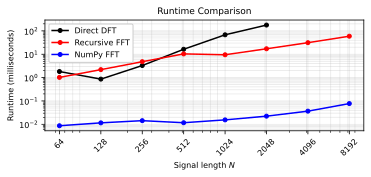

In [12]:
def measure_runtime(function, number=1, repeat=3):
    """Return the shortest average runtime."""
    return min(timeit.repeat(function, number=number,
                             repeat=repeat)) / number


sizes = 2 ** np.arange(6, 14)  # 64, ..., 8192
times_dft, times_fft, times_numpy = [], [], []

for N in sizes:
    n = np.arange(N)
    x = np.sin(2 * np.pi * n / N)

    # Large DFT matrices require too much memory
    t_dft = measure_runtime(lambda: dft(x)) if N <= 2048 else np.nan
    t_fft = measure_runtime(lambda: fft(x), number=3)
    t_numpy = measure_runtime(lambda: np.fft.fft(x), number=100)

    times_dft.append(t_dft)
    times_fft.append(t_fft)
    times_numpy.append(t_numpy)

    dft_text = f'{1000*t_dft:.3f}' if N <= 2048 else '---'
    print(f'N={N:4d}: DFT={dft_text:>8} ms, '
          f'FFT={1000*t_fft:8.3f} ms, '
          f'NumPy={1000*t_numpy:8.5f} ms')


plt.figure(figsize=(5.2, 2.5), layout='tight')

for times, style, label in [
    (times_dft, 'ko-', 'Direct DFT'),
    (times_fft, 'ro-', 'Recursive FFT'),
    (times_numpy, 'bo-', 'NumPy FFT'),
]:
    plt.loglog(sizes, 1000 * np.array(times),
               style, ms=4, label=label)

plt.title('Runtime Comparison')
plt.xlabel('Signal length $N$')
plt.ylabel('Runtime (milliseconds)')
plt.xticks(sizes, sizes, rotation=45)
plt.grid(alpha=0.3, which='both')
plt.legend(framealpha=1);

<a id="exercise_leakage"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 1: Frequency Bins and Spectral Leakage</strong>

<p style="color:#006064;">
Let <code>x</code> be a real-valued signal containing <code>N</code> samples acquired at a sampling rate <code>sr</code>, measured in samples per second. The DFT analyzes an interval of duration <code>N / sr</code> seconds, and the coefficient <code>X[k]</code> corresponds to the frequency <code>k * sr / N</code> Hz. Therefore, a sinusoid with frequency <code>freq</code> Hz lies exactly on a DFT bin if its theoretical bin position
</p>

<p style="color:#006064; text-align:center;">
<code>k_freq = freq * N / sr</code>
</p>

<p style="color:#006064;">
is an integer. Equivalently, the sinusoid must complete an integer number of cycles during the DFT analysis interval. In this case, the DFT magnitude of a real sinusoid is concentrated at the corresponding positive- and negative-frequency bins. If <code>k_freq</code> is not an integer, the magnitude is distributed across multiple bins, a phenomenon known as <strong>spectral leakage</strong>.
</p>

<p style="color:#006064;">
For each case below, generate a unit-amplitude sinusoid, compute its DFT, and plot the unnormalized one-sided magnitude spectrum using the nonnegative-frequency bins <code>k = 0, ..., N // 2</code>. Label the horizontal axis both by frequency index <code>k</code> and by frequency in Hertz.
</p>


<ul style="color:#006064; margin-bottom:0;">
  <li>Set <code>sr = 64</code> and <code>N = 64</code>, corresponding to a duration of one second. Compare sinusoids with <code>freq = 10</code> Hz and <code>freq = 10.5</code> Hz. Where do you observe spectral leakage?</li>
  <li>Keep <code>sr = 64</code> and <code>freq = 10.5</code> Hz, but set <code>N = 128</code>, corresponding to a duration of two seconds. How does the spectrum change?</li>
  <li>Use the bin spacing <code>sr / N</code> and the theoretical bin position <code>freq * N / sr</code> to explain your observations.</li>
</ul>
</div>

In [13]:
# Your Solution

10 Hz, one-second observation
  sr:                   64 Hz
  N:                    64
  duration:             1 s
  bin spacing:          1 Hz
  theoretical bin:      k = 10
  lies on a DFT bin:    yes


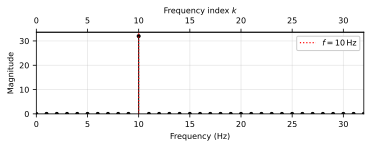

10.5 Hz, one-second observation
  sr:                   64 Hz
  N:                    64
  duration:             1 s
  bin spacing:          1 Hz
  theoretical bin:      k = 10.5
  lies on a DFT bin:    no


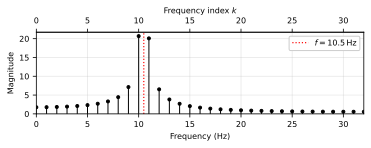

10.5 Hz, two-second observation
  sr:                   64 Hz
  N:                    128
  duration:             2 s
  bin spacing:          0.5 Hz
  theoretical bin:      k = 21
  lies on a DFT bin:    yes


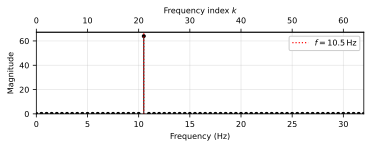

In [14]:
exercise_leakage()

<a id="exercise_missing_time"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 2: Frequency Content Without Time Localization</strong>

<p style="color:#006064;">
The DFT magnitude spectrum summarizes the frequency content of a signal over its entire analysis interval, but it does not directly indicate when individual frequencies occur. To explore this limitation, construct two signals over an interval of duration <code>T = 4</code> seconds using a sampling rate of <code>sr = 32</code> samples per second:
</p>

<ul style="color:#006064;">
  <li>A <strong>superposition</strong> of a sinusoid with <code>freq_1 = 1.1</code> Hz and amplitude <code>amp_1 = 1</code> and a sinusoid with <code>freq_2 = 3.9</code> Hz and amplitude <code>amp_2 = 0.5</code>. Both sinusoids are present throughout the entire interval.</li>
  <li>A <strong>concatenation</strong> in which the <code>1.1</code> Hz sinusoid occurs only during the first half of the interval and the <code>3.9</code> Hz sinusoid occurs only during the second half.</li>
</ul>

<p style="color:#006064;">
Set <code>N = T * sr</code> and generate the time axis using <code>t = np.arange(N) / sr</code>. For each signal, compute the DFT using <code>np.fft.fft</code> and plot the waveform together with its one-sided magnitude spectrum, with the frequency axis expressed in Hertz. Compare the dominant frequency regions in the two spectra. What information about the temporal arrangement of the frequencies is clearly visible in the waveforms but not directly apparent in the magnitude spectra?
</p>
</div>

In [15]:
# Your Solution

Superposition: Both frequencies occur throughout the signal


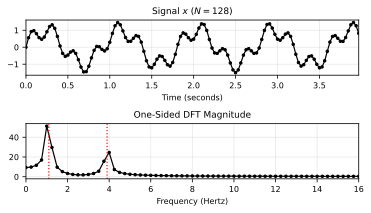

Concatenation: The frequencies occur at different times


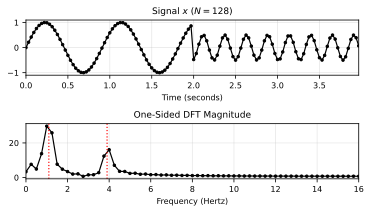

In [16]:
exercise_missing_time()

<a id="exercise_dft_inverse"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 3: Inverse DFT and Signal Reconstruction</strong>

<p style="color:#006064;">
The DFT matrix $\mathrm{DFT}_N\in\mathbb{C}^{N\times N}$ has an inverse $\mathrm{DFT}_N^{-1}\in\mathbb{C}^{N\times N}$. The two matrices are closely related:
$$
\mathrm{DFT}_N(k,n)
:=
\exp\left(-2\pi i\frac{kn}{N}\right),
\qquad
\mathrm{DFT}_N^{-1}(k,n)
:=
\frac{1}{N}\exp\left(2\pi i\frac{kn}{N}\right),
$$
for $k,n=0,\ldots,N-1$. Apart from the normalization factor $1/N$, the inverse DFT matrix is the conjugate transpose of the DFT matrix.
</p>

<ul style="color:#006064; margin-bottom:0;">
  <li>Implement <code>generate_matrix_dft_inv(N)</code> using the definition above.</li>
  <li>Compute <code>DFT @ DFT_inv</code> and <code>DFT_inv @ DFT</code>, and compare both products with the identity matrix using <code>np.eye</code> and <code>np.allclose</code>.</li>
  <li>Compute the inverse of the DFT matrix using <code>np.linalg.inv</code> and compare it with <code>generate_matrix_dft_inv(N)</code> using <code>np.allclose</code>.</li>
  <li>Apply the DFT followed by the inverse DFT to a real-valued test signal. Plot the original and reconstructed signals and report their maximum absolute difference.</li>
  <li>Implement <code>fft_inv(X)</code> and compare its result with <code>np.fft.ifft(X)</code>.</li>
</ul>
</div>

In [17]:
# Your Solution

DFT @ DFT_inv equals identity: True
DFT_inv @ DFT equals identity: True
Explicit inverse agrees with np.linalg.inv: True


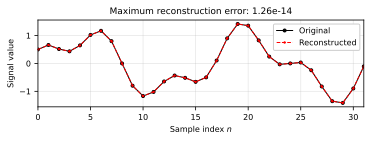

fft_inv agrees with np.fft.ifft: True


In [18]:
exercise_dft_inverse()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>